## DFT vs. MLIPs Energy Comparison

on DFT data for N on Ru slab and NH3 on Ru slab

#### 1. DFT data ingestion

In [48]:
from pathlib import Path
import numpy as np
from ase.io import iread, read, write

In [10]:
# load vasp trajectories into ASE Atoms obj.
# metadata: (system type, source dataset, external b-field strength)

def load_frames(path, system, source, bext: float):
    frames = []
    for f in iread(path):
        f.info["system"] = system
        f.info["source"] = source
        f.info["BEXT"] = bext
        frames.append(f)
    
    return frames

def load_frame(path, system, source, bext: float):
    frame = read(path)
    frame.info["system"] = system
    frame.info["source"] = source
    frame.info["BEXT"] = bext

    return frame

In [11]:
# ingest data for MLIP training set

ads = load_frames(
    "dft-data/NH3diss2_BEXT0.1/vasprun.xml",
    system="adsorbed",
    source="NH3diss",
    bext=0.1
)

slab = load_frame(
    "dft-data/NH3surf_BEXT0.1/vasprun.xml",
    system="slab",
    source="NH3surf",
    bext=0.1
)

gas = load_frame(
    "dft-data/NH3mag2_BEXT0.1/vasprun.xml",
    system="adsorbate",
    source="NH3mag2",
    bext=0.1
)

In [12]:
# write full trajectory + single frames for references (for model script handoff below)

write("input_slab_ads.xyz", ads)  # all frames
write("input_slab.xyz", slab)     # single frame
write("input_gas.xyz", gas)       # single frame

#### 2. run MLIPs (MACE, MatterSim, UMA)

In [50]:
# b/c different dependancies, each model should be run in its separate conda env
import subprocess
import os
env = os.environ.copy()
env["MPLBACKEND"] = "Agg"  # stop vscode from pulling bs

input_slab_ads_path = "model-scripts/script-data/input_slab_ads.xyz"
input_slab_path = "model-scripts/script-data/input_slab.xyz"
input_gas_path = "model-scripts/script-data/input_gas.xyz"

r1 = subprocess.run(
    ["/Users/zschwab/miniconda3/envs/mlip-mace/bin/python", "model-scripts/run_mace.py",
    input_slab_ads_path, input_slab_path, input_gas_path, "model-scripts/script-data/results_mace.npz"],
    capture_output=True, text=True, env=env
)

r2 = subprocess.run(
    ["/Users/zschwab/miniconda3/envs/mlip-mattersim/bin/python", "model-scripts/run_mattersim.py",
    input_slab_ads_path, input_slab_path, input_gas_path, "model-scripts/script-data/results_mattersim.npz"],
    capture_output=True, text=True, env=env
)

r3 = subprocess.run(
    ["/Users/zschwab/miniconda3/envs/mlip-uma/bin/python", "model-scripts/run_uma.py",
    input_slab_ads_path, input_slab_path, input_gas_path, "model-scripts/script-data/results_uma.npz"],
    capture_output=True, text=True, env=env
)

for name, r in [("MACE", r1), ("MatterSim", r2), ("UMA", r3)]:
    print(f"--- {name} ---")
    if r.stdout: print(r.stdout)
    if r.stderr: print(r.stderr)
    print("Return code:", r.returncode)

--- MACE ---
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
hello from mace!
Using Materials Project MACE for MACECalculator with /Users/zschwab/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
saving to: /Users/zschwab/vscode/montemore-research/ml-catalysis-research/model-scripts/script-data/results_mace.npz
cwd: /Users/zschwab/vscode/montemore-research/ml-catalysis-research

/Users/zschwab/miniconda3/envs/mlip-mace/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/Users/zschwab/miniconda3/envs/mlip-mace/lib/python3.11/site-packa

In [72]:
# convert dft frames to npz for ease of reading later

dft_frames = read("model-scripts/script-data/input_slab_ads.xyz", index=":")
dft_energies = np.array([atoms.get_potential_energy() for atoms in dft_frames])

dft_slab_energy = read("model-scripts/script-data/input_slab.xyz")
dft_gas_energy = read("model-scripts/script-data/input_gas.xyz")

np.savez("model-scripts/script-data/results_dft.npz",
         mlip_energies=dft_energies,  # reuse same key name for consistency
         slab_energy=dft_energies[0], # adjust indices to match your data
         gas_energy=dft_energies[1])

In [ ]:
# peek at model results

mace      = np.load("model-scripts/script-data/results_mace.npz")
mattersim = np.load("model-scripts/script-data/results_mattersim.npz")
uma       = np.load("model-scripts/script-data/results_uma.npz")

dft_frames = read("model-scripts/script-data/input_slab_ads.xyz", index=":")
dft = {
    "mlip_energies": np.array([a.get_potential_energy() for a in dft_frames]),  # not the right category but fits keying
    "slab_energy":   read("model-scripts/script-data/input_slab.xyz").get_potential_energy(),
    "gas_energy":    read("model-scripts/script-data/input_gas.xyz").get_potential_energy(),
}

for name, res in [("MACE", mace), ("MatterSim", mattersim), ("UMA", uma), ("DFT", dft)]:
    print(f"\n--- {name} ---")
    print(f"  frames:      {len(res['mlip_energies'])}")
    print(f"  energies:    {res['mlip_energies']}")
    print(f"  slab_energy: {res['slab_energy']:.4f} eV")
    print(f"  gas_energy:  {res['gas_energy']:.4f} eV")
    print(f"  E_ads:       {res['mlip_energies'][-1] - res['slab_energy'] - res['gas_energy']:.4f} eV")


--- MACE ---
  frames:      11
  energies:    [-342.86700439 -342.86315918 -342.85620117 -342.85543823 -342.85437012
 -342.85467529 -342.85577393 -342.85812378 -342.86233521 -342.86767578
 -342.86810303]
  slab_energy: -322.3755 eV
  gas_energy:  -19.5073 eV
  E_ads:       -0.9853 eV

--- MatterSim ---
  frames:      11
  energies:    [-337.03015 -337.03357 -337.03687 -337.03738 -337.03928 -337.04056
 -337.04166 -337.0433  -337.04556 -337.04822 -337.04813]
  slab_energy: -316.8417 eV
  gas_energy:  -19.5013 eV
  E_ads:       -0.7052 eV

--- UMA ---
  frames:      11
  energies:    [-311.83094885 -311.83167599 -311.83127612 -311.83148959 -311.83206932
 -311.83248129 -311.83294796 -311.83373693 -311.83494371 -311.83636693
 -311.83638595]
  slab_energy: -291.7771 eV
  gas_energy:  -19.3920 eV
  E_ads:       -0.6673 eV

--- DFT ---
  frames:      11
  energies:    [-359.36884848 -359.3712598  -359.37130666 -359.37230854 -359.37252974
 -359.37256537 -359.37274717 -359.37292797 -359.3733231

#### 3. plot results (model E<sub>slab+ads</sub> vs. DFT E<sub>slab+ads</sub>)

In [52]:
import matplotlib.pyplot as plt

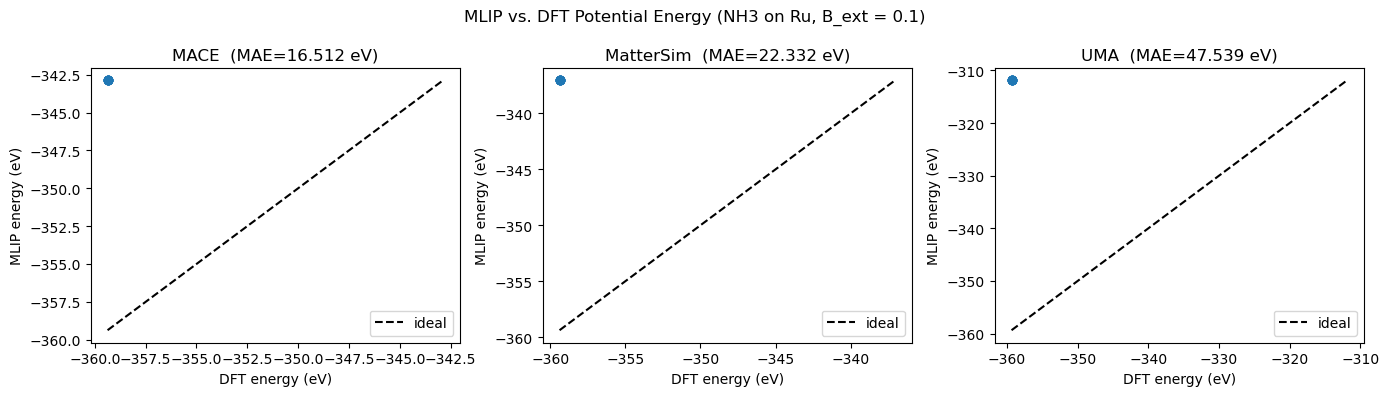

In [97]:
dft_energies = np.array([f.get_potential_energy() for f in ads])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("MLIP vs. DFT Potential Energy (NH3 on Ru, B_ext = 0.1)")

for ax, (name, res) in zip(axes, [("MACE", mace), ("MatterSim", mattersim), ("UMA", uma)]):
    mlip_e = res["mlip_energies"]
    
    ax.scatter(dft_energies, mlip_e, alpha=0.7)
    
    # ideal parity line
    lims = [min(dft_energies.min(), mlip_e.min()), 
            max(dft_energies.max(), mlip_e.max())]
    ax.plot(lims, lims, 'k--', label="ideal")
    
    mae = np.mean(np.abs(mlip_e - dft_energies))
    ax.set_title(f"{name}  (MAE={mae:.3f} eV)")
    ax.set_xlabel("DFT energy (eV)")
    ax.set_ylabel("MLIP energy (eV)")
    ax.legend()

plt.tight_layout()
plt.show()

In [58]:
print("DFT energy range:", dft_energies.min(), "to", dft_energies.max())
print("MACE energy range:", mace["mlip_energies"].min(), "to", mace["mlip_energies"].max())

DFT energy range: -359.3737334 to -359.36884848
MACE energy range: -342.86810302734375 to -342.8543701171875


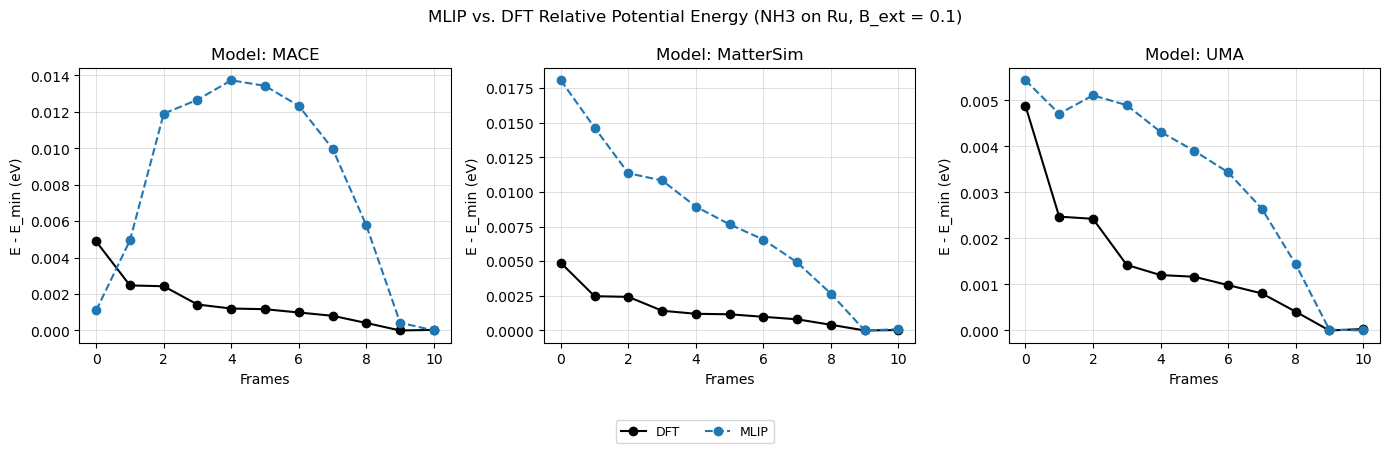

In [98]:
# remove absolute offset (subtract lowest point) to better see MLIPs vs. DFT energy frame by frame

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("MLIP vs. DFT Relative Potential Energy (NH3 on Ru, B_ext = 0.1)")

frames = range(len(dft_energies))
dft_rel = dft_energies - dft_energies.min()

for ax, (name, res) in zip(axes, [("MACE", mace), ("MatterSim", mattersim), ("UMA", uma)]):
    mlip_e = np.array(res["mlip_energies"])
    mlip_rel = mlip_e - mlip_e.min()
    ax.plot(frames, dft_rel, 'k-o', label="DFT")
    ax.plot(frames, mlip_rel, '--o', label=name)
    ax.set_ylabel("E - E_min (eV)")
    ax.set_xlabel("Frames")
    ax.set_title("Model: " + name)
    ax.grid(color='lightgrey', linestyle='-', linewidth=0.5)

# make shared legend
handles, labels = axes[0].get_legend_handles_labels()
labels[1] = "MLIP"
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.12), fontsize=9)

plt.tight_layout()
plt.show()

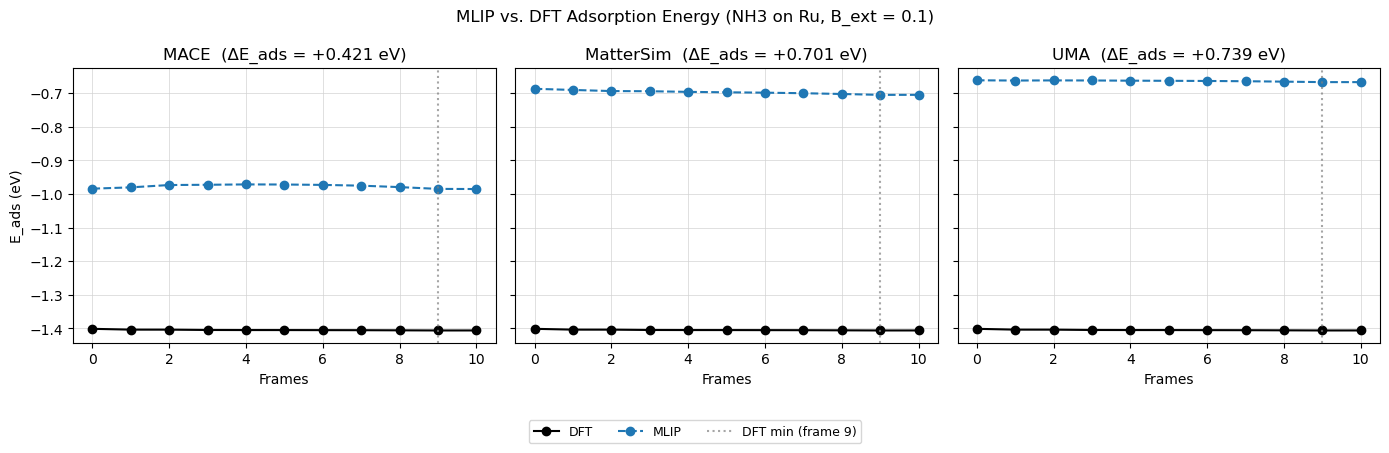

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("MLIP vs. DFT Relative Adsorption Energy (NH3 on Ru, B_ext = 0.1)")
frames = range(len(dft_energies))

dft_e = np.array(dft["mlip_energies"])
dft_ads = dft_e - dft["slab_energy"] - dft["gas_energy"]
dft_min_frame = np.argmin(dft_ads)

for ax, (name, res) in zip(axes, [("MACE", mace), ("MatterSim", mattersim), ("UMA", uma)]):
    mlip_e = np.array(res["mlip_energies"])
    mlip_ads = mlip_e - res["slab_energy"] - res["gas_energy"]
    e_ads_error = mlip_ads[dft_min_frame] - dft_ads[dft_min_frame]

    ax.plot(frames, dft_ads, 'k-o', label="DFT")
    ax.plot(frames, mlip_ads, '--o', label=name)
    ax.axvline(dft_min_frame, color='gray', linestyle=':', alpha=0.7, label=f"DFT min (frame {dft_min_frame})")

    ax.set_ylabel("E_ads (eV)" if ax == axes[0] else "")
    ax.set_xlabel("Frames")
    ax.set_title(f"{name}  (ΔE_ads = {e_ads_error:+.3f} eV)")
    ax.grid(color='lightgrey', linestyle='-', linewidth=0.5)

# single legend: grab handles from last ax, deduplicate labels
handles, labels = axes[0].get_legend_handles_labels()
# replace model-specific label with generic one for the shared legend
labels[1] = "MLIP"
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.12), fontsize=9)

plt.tight_layout()
plt.show()